In [2]:
from EngFinancialPy import *
import numpy_financial as npf 
import numpy as np
from scipy import stats

### Cashflow of Base Cases

#### Alternative I

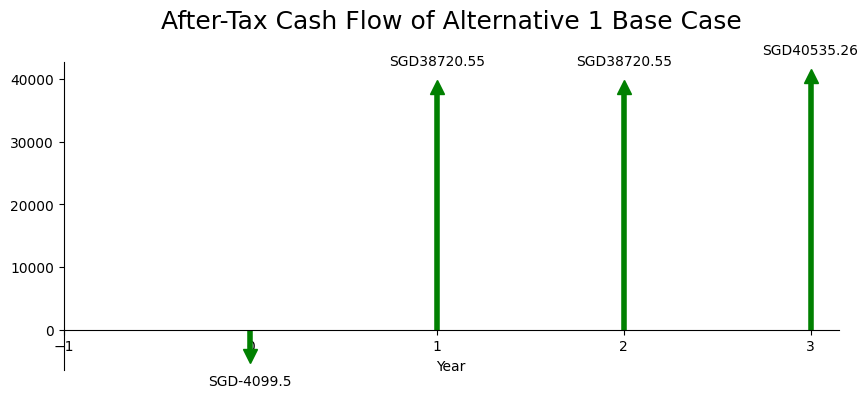

In [13]:
CF1 = np.array([-4099.50, 38720.55, 38720.55, 38720.55 + 1814.71])
D1 = CF_diagram(CF1, color='green', currency='SGD',
time_start=-1, time_end=3, figsize=(10, 4),
title="After-Tax Cash Flow of Alternative 1 Base Case")

D1.axes.get_yaxis().set_visible(True)
D1.axes.spines['left'].set_visible(True)
plt.show()

#### Alternative II

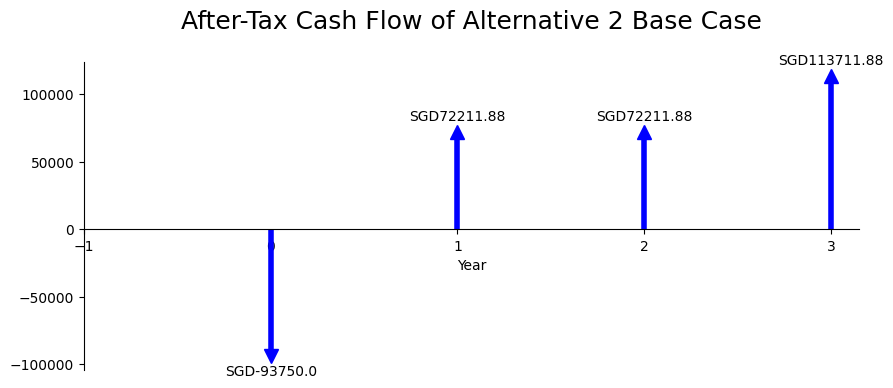

In [12]:
CF2 = np.array([-93750, 72211.88, 72211.88, 72211.88 + 41500])
D2 = CF_diagram(CF2, color='blue', currency='SGD',
time_start=-1, time_end=3, figsize=(10, 4),
title="After-Tax Cash Flow of Alternative 2 Base Case")

D2.axes.get_yaxis().set_visible(True)
D2.axes.spines['left'].set_visible(True)
plt.show()

#### Alternative 3

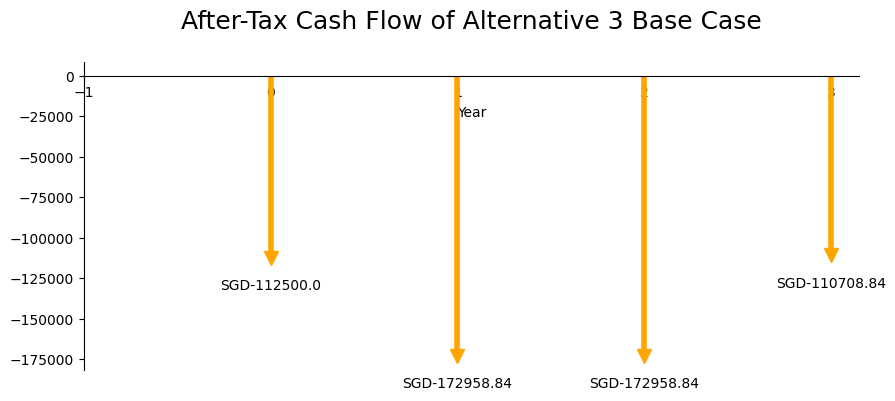

In [15]:
CF3 = np.array([-112500, -172958.84, -172958.84, -172958.84+62250])
D3 = CF_diagram(CF3, color='orange', currency='SGD',
time_start=-1, time_end=3, figsize=(10, 4),
title="After-Tax Cash Flow of Alternative 3 Base Case")

D3.axes.get_yaxis().set_visible(True)
D3.axes.spines['left'].set_visible(True)
plt.show()

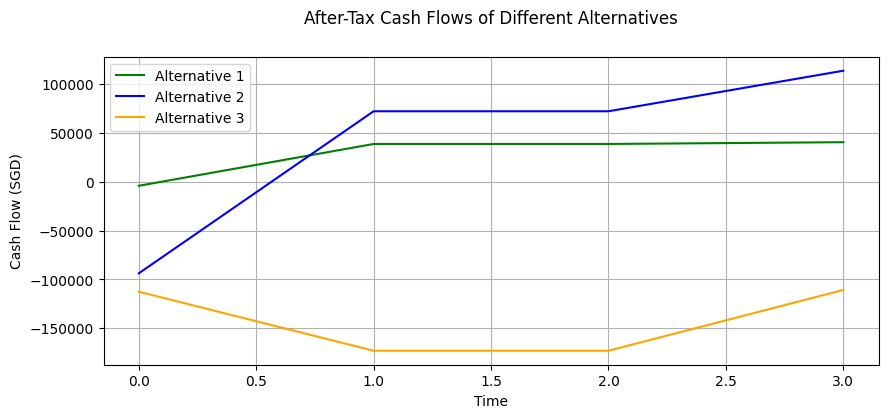

In [19]:
# Plot each cash flow diagram
plt.figure(figsize=(10, 4))

# Define the x-axis values
x_values = range(0, 4)

plt.plot(x_values, CF1, label='Alternative 1', color='green')
plt.plot(x_values, CF2, label='Alternative 2', color='blue')
plt.plot(x_values, CF3, label='Alternative 3', color='orange')

plt.title("After-Tax Cash Flows of Different Alternatives")
plt.xlabel("Time")
plt.ylabel("Cash Flow (SGD)")
plt.legend()
plt.grid(True)
plt.show()


## Simulation on Alternative I

#### Initial Setup Costs, I: Triangular Distribution (a = 4500, b = 6076, mode = 5466)
#### One-off Subsidy, G: Triangular Distribution (a = 0, b = 2250, mode = 1366.6)
#### Annual Benefits, B: Normal Distribution (mu = 90230.61525, sigma = 20000)
#### O & M Costs, E: Triangular Distribution (a = 1200, b = 3000, mode = 2100)
#### Shrinkage Costs, S: Normal Distribution (mu = 159.2304975, sigma = 1.5)
#### Market Value, MV: Normal Distribution (mu = 2186, sigma = 50)

##### Fixed Data: MARR = 10%, Study Period = 3 years

In [4]:
fixed_vars = {'marr': 0.1, 'study_period' : 3}

random_vars1 = {'I' : stats.triang(c=(5466 - 4500) / (6076 - 4500), loc=4500, scale=(6076 - 4500)), 
               'G' : stats.triang(c=(1366.6 - 0) / 2250, loc=0, scale=2250), 
               'B': stats.norm(90230.61525,20000), 
               'E' : stats.triang(c=(2100 - 1200) / (3000 - 1200), loc=1200, scale=(3000 - 1200)),
               'M' : stats.uniform(loc=33280, scale=(49920 - 33280)),
               'S' : stats.norm(159.2304975, 1.5),
               'MV' : stats.norm(2186.4,50)}


In [244]:
def PW1(marr, study_period, I, G, B, E, M, S, MV): 
    return (G-I) - npf.pv(marr, study_period, B - E - M - S, MV)

def IRR1(marr, study_period, I, G, B, E, M, S, MV): 
    return npf.rate(study_period, B - E - M - S, G-I, MV)

In [245]:
output_functions1 = {'PW of Alt 1': PW1, 'IRR of Alt 1': IRR1 }

In [246]:
sim_model1 = Monte_Carlo_Simulation(fixed_vars,random_vars1,output_functions1)

Simulation Completed

Input Variable I:
count    100000.00
mean       5346.98
std         325.22
min        4501.56
25%        5114.94
50%        5371.10
75%        5586.20
max        6073.11
Name: I, dtype: float64

Histogram:


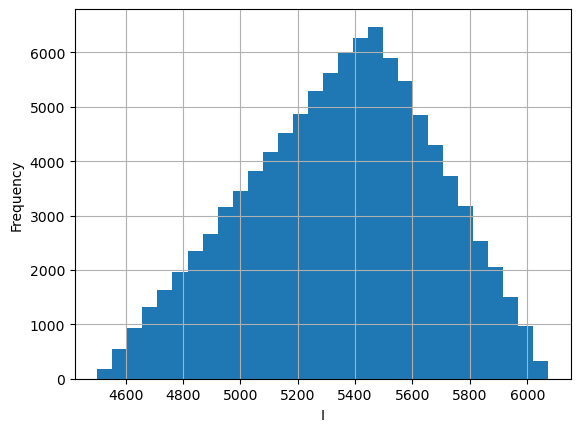


Input Variable G:
count    100000.00
mean       1207.17
std         461.37
min           5.58
25%         879.66
50%        1240.47
75%        1545.33
max        2246.53
Name: G, dtype: float64

Histogram:


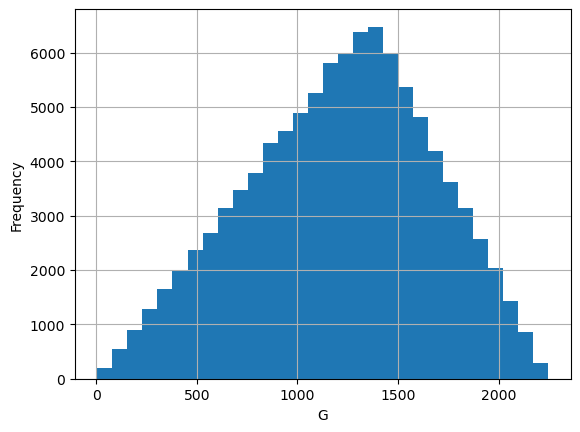


Input Variable B:
count    100000.00
mean      90155.57
std       19979.54
min       10402.47
25%       76637.00
50%       90163.38
75%      103653.67
max      171683.11
Name: B, dtype: float64

Histogram:


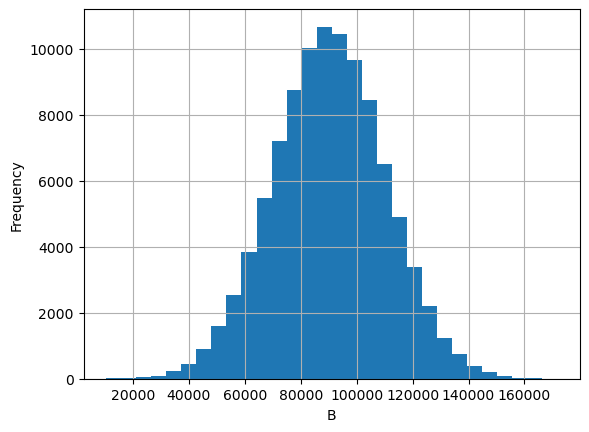


Input Variable E:
count    100000.00
mean       2099.36
std         367.93
min        1204.83
25%        1835.36
50%        2099.54
75%        2363.61
max        2994.55
Name: E, dtype: float64

Histogram:


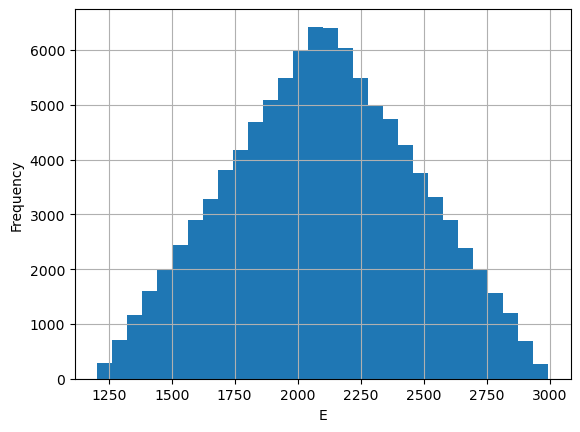


Input Variable M:
count    100000.00
mean      41590.12
std        4802.25
min       33280.11
25%       37437.17
50%       41585.80
75%       45765.69
max       49919.98
Name: M, dtype: float64

Histogram:


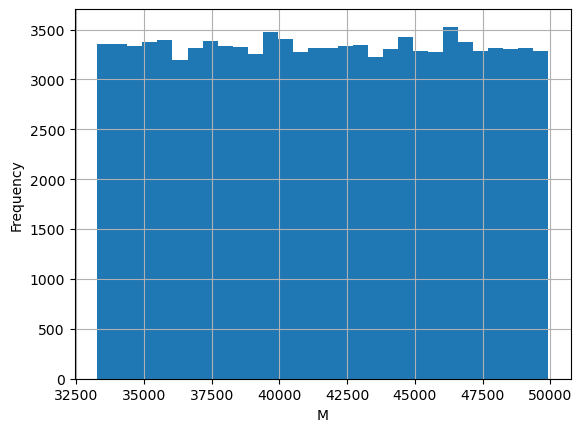


Input Variable S:
count    100000.00
mean        159.23
std           1.50
min         152.55
25%         158.22
50%         159.23
75%         160.24
max         165.67
Name: S, dtype: float64

Histogram:


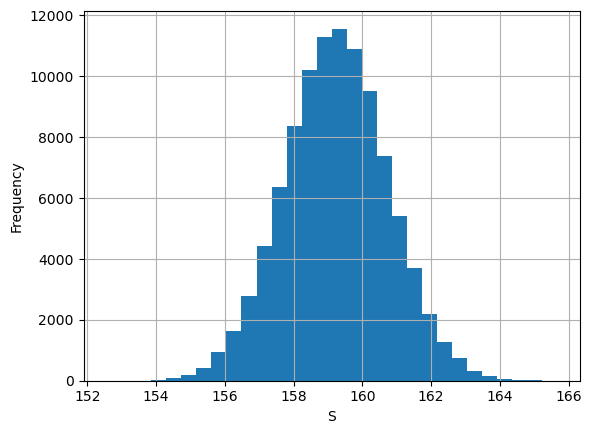


Input Variable MV:
count    100000.00
mean       2186.11
std          50.03
min        1979.55
25%        2152.54
50%        2185.97
75%        2219.90
max        2400.29
Name: MV, dtype: float64

Histogram:


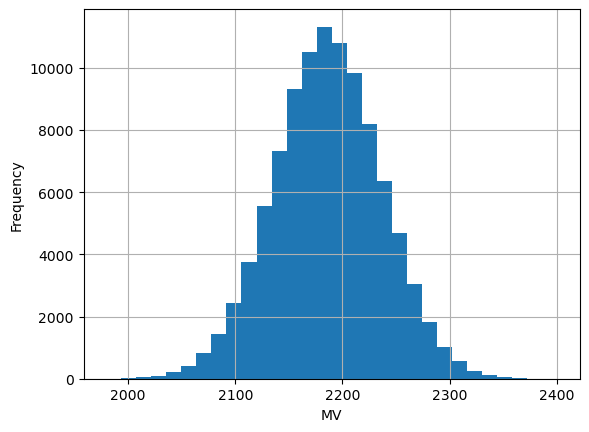

In [247]:
status1 = sim_model1.run(num_trials=100000) 
print(status1)
sim_model1.show_inputs_values()


Output Variable PW of Alt 1:
count     99999.00
mean     112663.13
std       51053.19
min      -90125.42
25%       78258.21
50%      112664.42
75%      147109.00
max      312854.01
Name: PW of Alt 1, dtype: float64

Histogram:


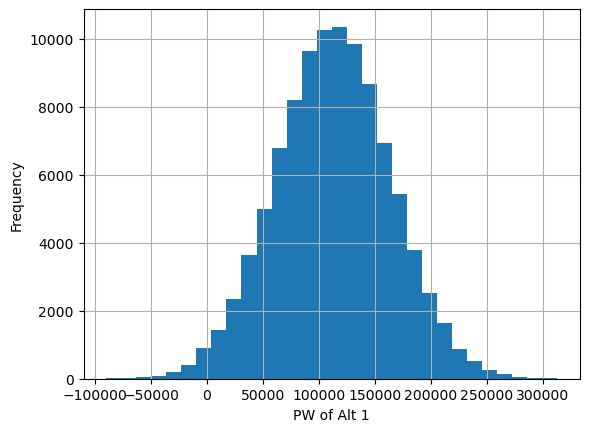

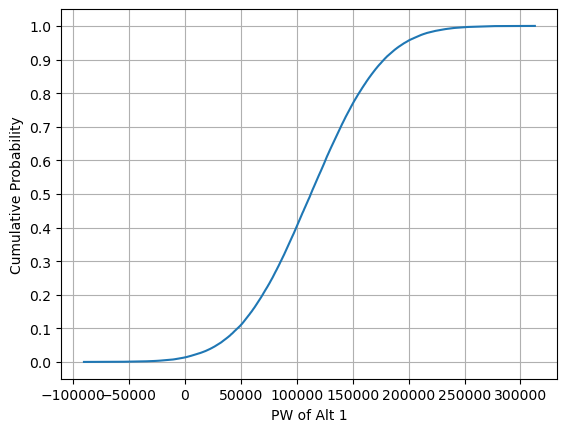

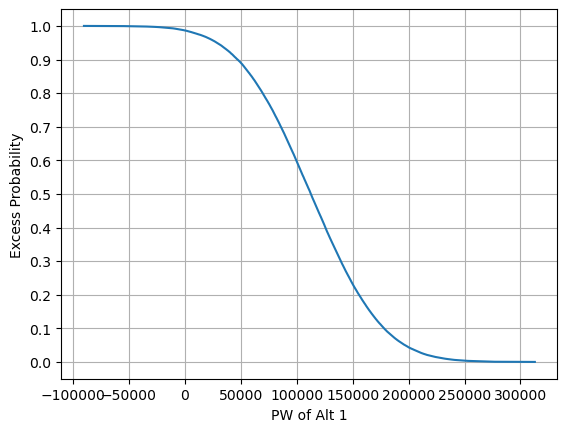


Output Variable IRR of Alt 1:
count    77725.00
mean        10.54
std          5.19
min        -10.27
25%          7.06
50%         10.30
75%         13.82
max         31.34
Name: IRR of Alt 1, dtype: float64

Histogram:


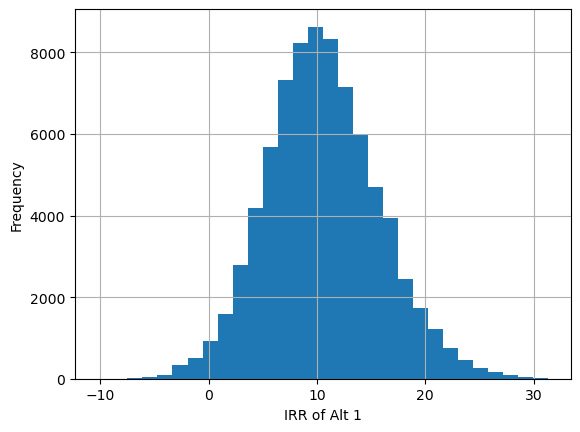

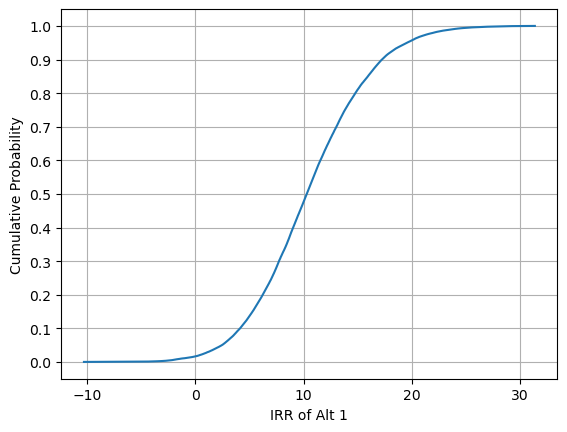

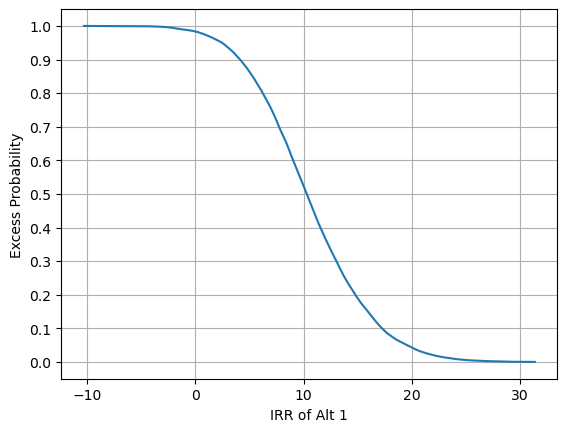

In [249]:
sim_model1.show_outputs_values()

In [253]:
sim_model1.Prob_Analysis_DCF('PW of Alt 1', 
                             downsides=[-10000,-5000, 0], 
                             upsides=[50000, 100000, 150000, 200000, 250000])


Probabilistic Analysis on PW of Alt 1
  EV = 112,668.39
  SD = 50,926.40
Downside Risks:
  Pr(PW of Alt 1 <= -10,000) = 0.73%
  Pr(PW of Alt 1 <=  -5,000) = 1.01%
  Pr(PW of Alt 1 <=       0) = 1.32%
Upside Potentials:
  Pr(PW of Alt 1 >=  50,000) = 89.08%
  Pr(PW of Alt 1 >= 100,000) = 59.78%
  Pr(PW of Alt 1 >= 150,000) = 23.18%
  Pr(PW of Alt 1 >= 200,000) = 4.34%
  Pr(PW of Alt 1 >= 250,000) = 0.35%
Value-at-Risk:
  VaR(99%) =   5,167.38
  VaR(95%) = -28,739.08
  VaR(90%) = -47,190.01


In [254]:
marr = fixed_vars['marr'] 
sim_model1.Prob_Analysis_rate('IRR of Alt 1', marr, 
                              downsides =[marr-0.025, marr-0.05, marr-0.1], 
                              upsides=[0.1, 0.15, 0.2, 0.25])


Probabilistic Analysis on IRR of Alt 1:
  EV = 1,052.35%
  SD = 516.11%
Downside Risks:
  Pr(IRR of Alt 1 <= 10.0%) = 1.71%
  Pr(IRR of Alt 1 <=  7.5%) = 1.70%
  Pr(IRR of Alt 1 <=  5.0%) = 1.67%
  Pr(IRR of Alt 1 <=  0.0%) = 1.63%
Upside Potentials:
  Pr(IRR of Alt 1 >= 10.0%) = 98.29%
  Pr(IRR of Alt 1 >= 15.0%) = 98.25%
  Pr(IRR of Alt 1 >= 20.0%) = 98.21%
  Pr(IRR of Alt 1 >= 25.0%) = 98.16%


## Simulation on Alternative II

#### Initial Setup Costs, I: Triangular Distribution (a = 110000, b = 150000, mode = 125000)
#### One-off Subsidy, G: Triangular Distribution (a = 0, b = 55000, mode = 31250)
#### Annual Benefits, B: Normal Distribution (mu = 159230.5, sigma = 30000)
#### O & M Costs, E: Triangular Distribution (a = 20352, b = 21690.30, mode = 20675.05)
#### Shrinkage Costs, S: Normal Distribution (mu = 21000, sigma = 500)
#### Market Value, MV: Normal Distribution (mu = 50000, sigma = 150)

##### Fixed Data: MARR = 10%, Study Period = 3 years

In [22]:
random_vars2 = {'I': stats.triang(c=(125000 - 110000) / (150000 - 110000), loc=110000, scale=(150000 - 110000)), 
                'G': stats.triang(c=(31250 - 0) / (55000 - 0), loc=0, scale=(55000)), 
                'B': stats.norm(159230.5, 30000), 
                'E': stats.triang(c=(20675.05 - 20352) / (21690.30 - 20352), loc=20675.05, scale=(21690.30 - 20352)), 
                'M': stats.uniform(loc=16640, scale=(24960 - 16640)), 
                'S': stats.norm(21000, 500), 
                'MV': stats.norm(50000, 150)}

In [23]:
def PW2(marr, study_period, I, G, B, E, M, S, MV): 
    return (G-I) - npf.pv(marr, study_period, B - E - M - S, MV)

def IRR2(marr, study_period, I, G, B, E, M, S, MV): 
    return npf.rate(study_period, B - E - M - S, G-I, MV)

In [24]:
output_functions2 = {'PW of Alt 2': PW2, 'IRR of Alt 2': IRR2 }

In [25]:
sim_model2 = Monte_Carlo_Simulation(fixed_vars,random_vars2,output_functions2)

Simulation Completed

Input Variable I:
count    100000.00
mean     128354.95
std        8241.61
min      110039.53
25%      122277.96
50%      127691.98
75%      134201.46
max      149843.69
Name: I, dtype: float64

Histogram:


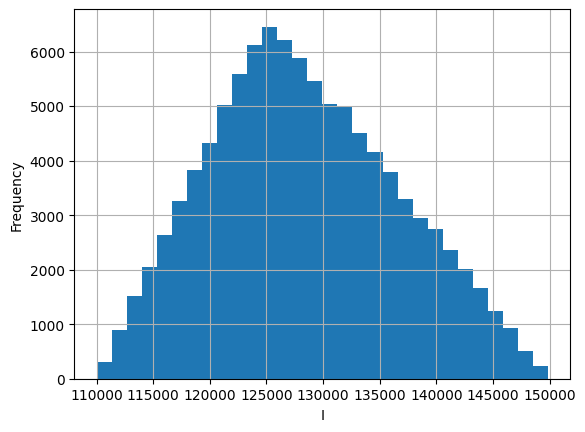


Input Variable G:
count    100000.00
mean      28823.32
std       11242.94
min          99.81
25%       20788.16
50%       29421.35
75%       36996.79
max       54908.67
Name: G, dtype: float64

Histogram:


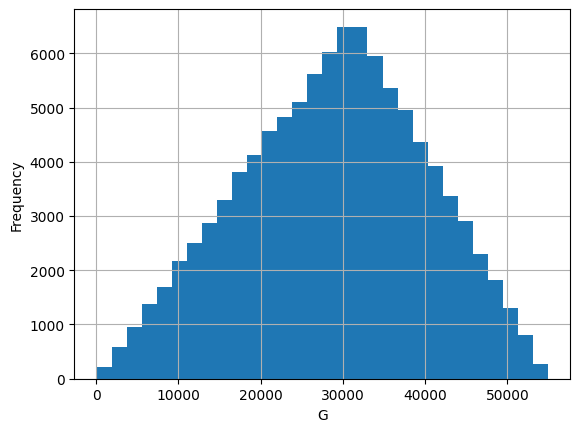


Input Variable B:
count    100000.00
mean     159099.09
std       30096.51
min       40419.15
25%      138697.51
50%      159140.97
75%      179422.43
max      295466.88
Name: B, dtype: float64

Histogram:


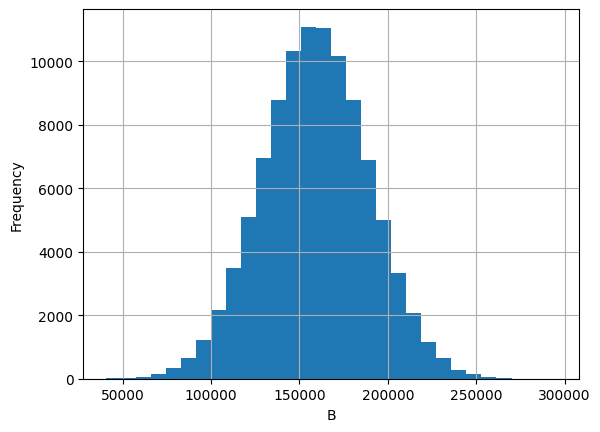


Input Variable E:
count    100000.00
mean      21229.06
std         284.54
min       20677.29
25%       21004.95
50%       21189.50
75%       21430.54
max       22005.86
Name: E, dtype: float64

Histogram:


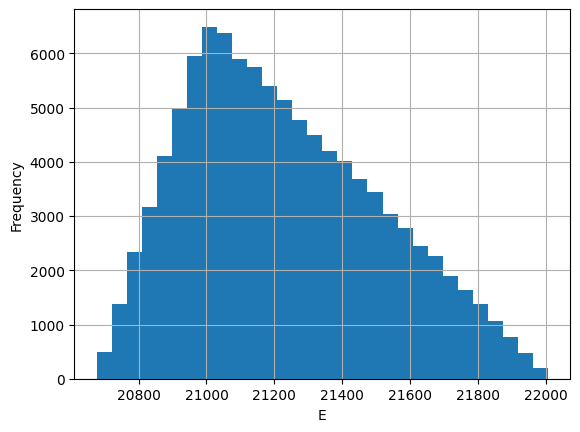


Input Variable M:
count    100000.00
mean      20801.19
std        2399.79
min       16640.04
25%       18717.41
50%       20799.96
75%       22891.25
max       24959.96
Name: M, dtype: float64

Histogram:


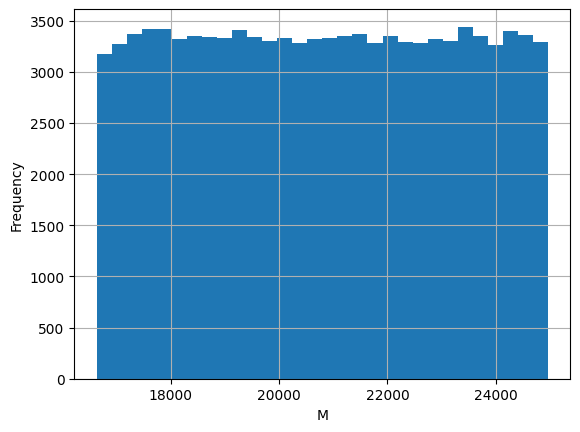


Input Variable S:
count    100000.00
mean      20998.99
std         501.25
min       18714.70
25%       20662.43
50%       20998.68
75%       21337.35
max       23043.17
Name: S, dtype: float64

Histogram:


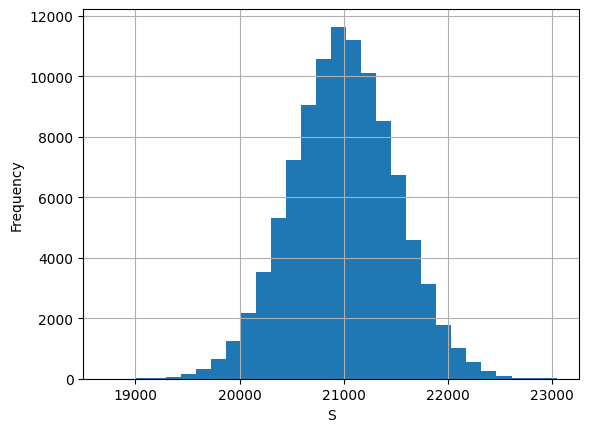


Input Variable MV:
count    100000.00
mean      50000.06
std         149.72
min       49378.13
25%       49898.89
50%       49999.51
75%       50101.51
max       50617.65
Name: MV, dtype: float64

Histogram:


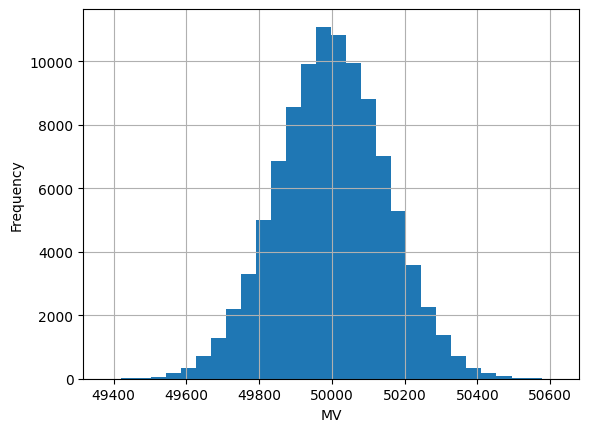

In [26]:
status2 = sim_model2.run(num_trials=100000) 
print(status2)
sim_model2.show_inputs_values()


Output Variable PW of Alt 2:
count     99991.00
mean     176922.67
std       76397.19
min     -127376.93
25%      125389.56
50%      177140.41
75%      228794.28
max      474801.59
Name: PW of Alt 2, dtype: float64

Histogram:


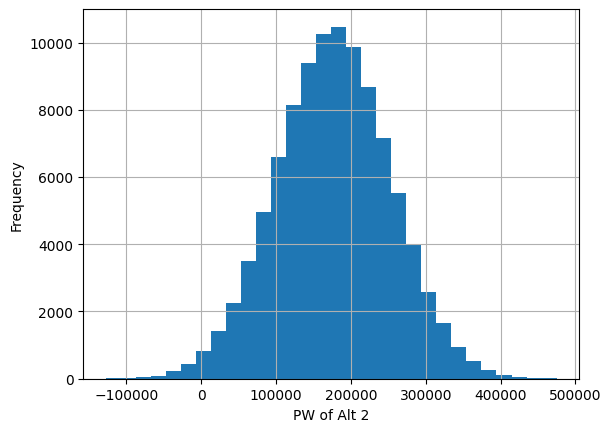

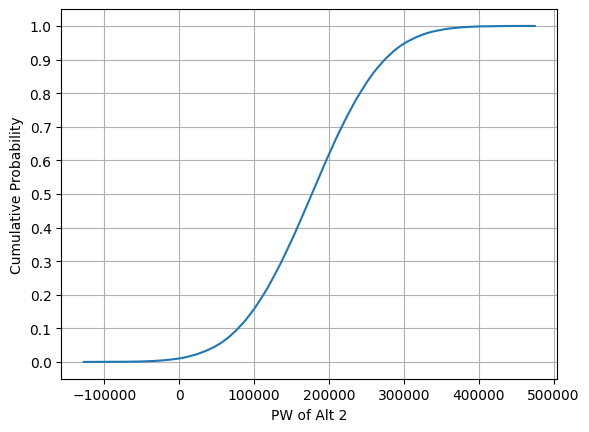

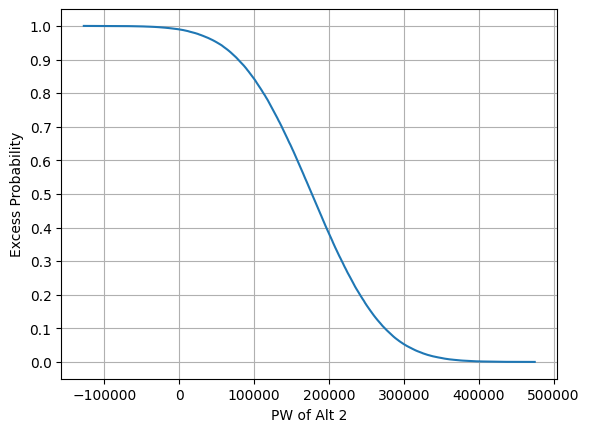


Output Variable IRR of Alt 2:
count    99822.00
mean         0.90
std          0.37
min         -0.55
25%          0.65
50%          0.89
75%          1.14
max          2.38
Name: IRR of Alt 2, dtype: float64

Histogram:


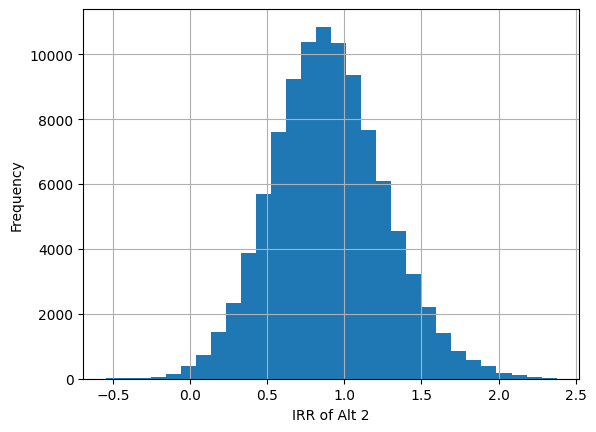

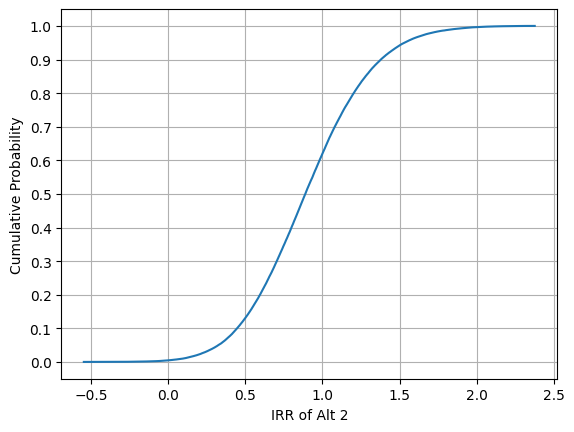

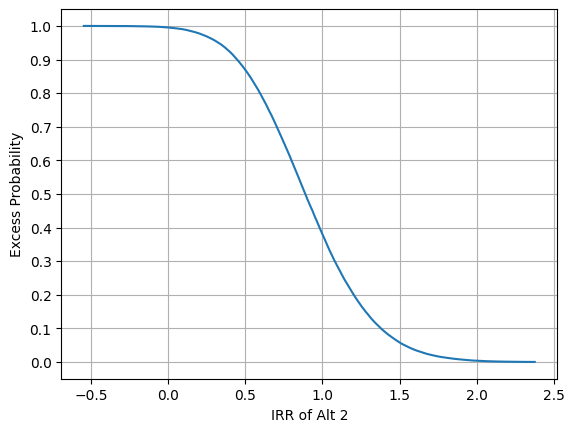

In [27]:
sim_model2.show_outputs_values()

In [28]:
sim_model2.Prob_Analysis_DCF('PW of Alt 2', 
                             downsides=[-75000,-50000,-25000, 0], 
                             upsides=[100000, 200000, 300000, 400000])


Probabilistic Analysis on PW of Alt 2
  EV = 176,929.34
  SD = 76,239.99
Downside Risks:
  Pr(PW of Alt 2 <= -75,000) = 0.03%
  Pr(PW of Alt 2 <= -50,000) = 0.12%
  Pr(PW of Alt 2 <= -25,000) = 0.39%
  Pr(PW of Alt 2 <=       0) = 1.01%
Upside Potentials:
  Pr(PW of Alt 2 >= 100,000) = 84.26%
  Pr(PW of Alt 2 >= 200,000) = 38.21%
  Pr(PW of Alt 2 >= 300,000) = 5.29%
  Pr(PW of Alt 2 >= 400,000) = 0.14%
Value-at-Risk:
  VaR(99%) =     363.36
  VaR(95%) = -51,024.94
  VaR(90%) = -78,709.89


In [29]:
marr = fixed_vars['marr'] 
sim_model2.Prob_Analysis_rate('IRR of Alt 2', marr, 
                              downsides =[marr-0.025, marr-0.05, marr-0.1], 
                              upsides=[0.1, 0.15, 0.2, 0.25])


Probabilistic Analysis on IRR of Alt 2:
  EV = 90.24%
  SD = 36.55%
Downside Risks:
  Pr(IRR of Alt 2 <= 10.0%) = 1.02%
  Pr(IRR of Alt 2 <=  7.5%) = 0.86%
  Pr(IRR of Alt 2 <=  5.0%) = 0.70%
  Pr(IRR of Alt 2 <=  0.0%) = 0.46%
Upside Potentials:
  Pr(IRR of Alt 2 >= 10.0%) = 98.98%
  Pr(IRR of Alt 2 >= 15.0%) = 98.49%
  Pr(IRR of Alt 2 >= 20.0%) = 97.81%
  Pr(IRR of Alt 2 >= 25.0%) = 96.88%


## Simulation on Alternative III

#### Initial Setup Costs, I: Triangular Distribution (a = 94900, b = 1000000, mode = 150000)
#### One-off Subsidy, G: Triangular Distribution (a = 0, b = 47450, mode = 37500)
#### Annual Benefits, B: Normal Distribution (mu = 53076.8325, sigma = 4500)
#### O & M Costs, E: Triangular Distribution (a = 230078.856, b = 271309.182, mode = 250694.019)
#### Shrinkage Costs, S: Normal Distribution (mu = 3230.733, sigma = 400)
#### Market Value, MV: Normal Distribution (mu = 75000, sigma = 5000)

##### Fixed Data: MARR = 10%, Study Period = 3 years

In [7]:
random_vars3 = {'I' : stats.triang(c=(150000 - 94900) / (1000000 - 94900), loc=94900, scale=(1000000 - 94900)), 
               'G' : stats.triang(c=(37500 - 0) / 47450, loc=0, scale=47450), 
               'B': stats.norm(53076.8325, 4500), 
               'E' : stats.triang(c=(250694.019 - 230078.856) / (271309.182 - 230078.856), loc=230078.856, scale=(271309.182 - 230078.856)),
               'M' : stats.uniform(loc=11680, scale=(14600 - 11680)),
               'S' : stats.norm(320.733, 400),
               'MV' : stats.norm(75000,5000)}

In [8]:
def PW3(marr, study_period, I, G, B, E, M, S, MV): 
    return (G-I) - npf.pv(marr, study_period, B - E - M - S, MV)

def IRR3(marr, study_period, I, G, B, E, M, S, MV): 
    return npf.rate(study_period, B - E - M - S, G-I, MV)

In [9]:
output_functions3 = {'PW of Alt 3': PW3, 'IRR of Alt 3': IRR3 }

In [10]:
sim_model3 = Monte_Carlo_Simulation(fixed_vars,random_vars3,output_functions3)

Simulation Completed

Input Variable I:
count    1000000.00
mean      414935.43
std       206940.71
min        95033.26
25%       240561.29
50%       379942.80
75%       561087.80
max       999480.23
Name: I, dtype: float64

Histogram:


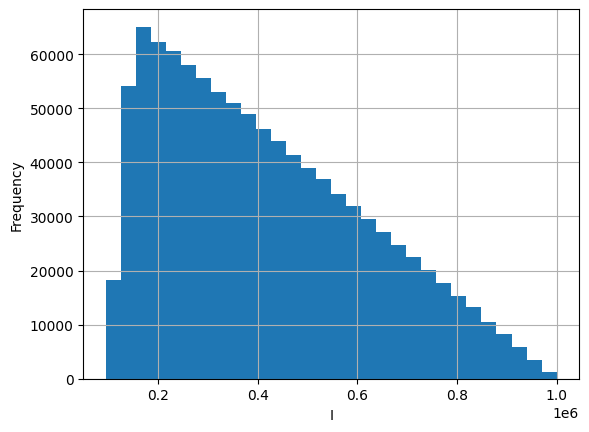


Input Variable G:
count    1000000.00
mean       28311.66
std        10217.36
min           38.84
25%        21081.26
50%        29816.46
75%        36528.41
max        47431.59
Name: G, dtype: float64

Histogram:


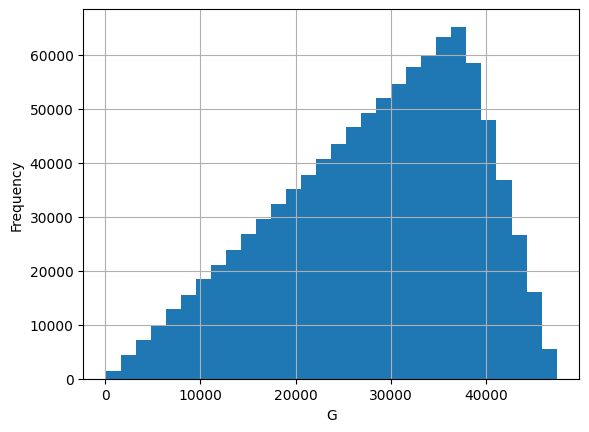


Input Variable B:
count    1000000.00
mean       53077.47
std         4493.92
min        31234.21
25%        50047.79
50%        53074.68
75%        56108.45
max        73970.92
Name: B, dtype: float64

Histogram:


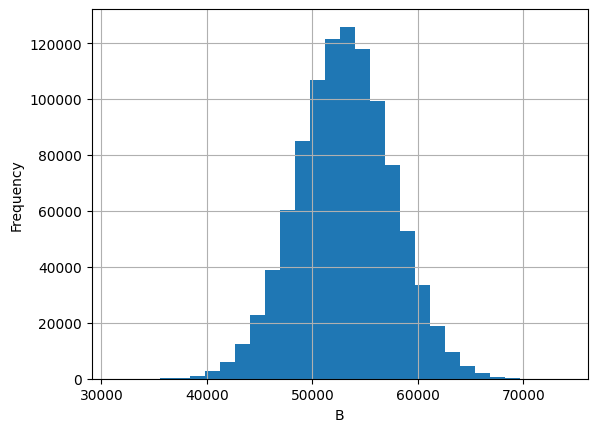


Input Variable E:
count    1000000.00
mean      250691.40
std         8417.81
min       230083.45
25%       244657.20
50%       250690.79
75%       256721.72
max       271284.66
Name: E, dtype: float64

Histogram:


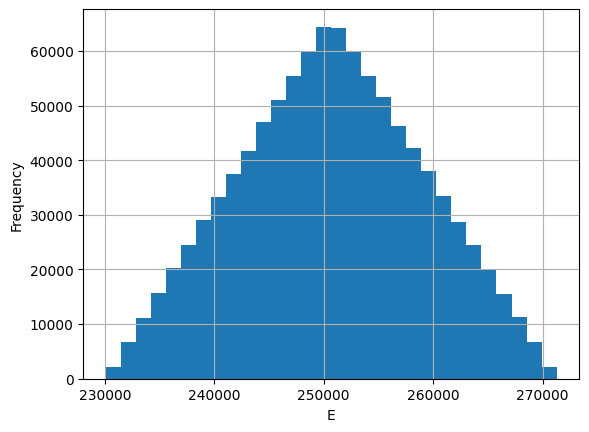


Input Variable M:
count    1000000.00
mean       13139.90
std          842.73
min        11680.00
25%        12410.11
50%        13139.38
75%        13869.48
max        14599.99
Name: M, dtype: float64

Histogram:


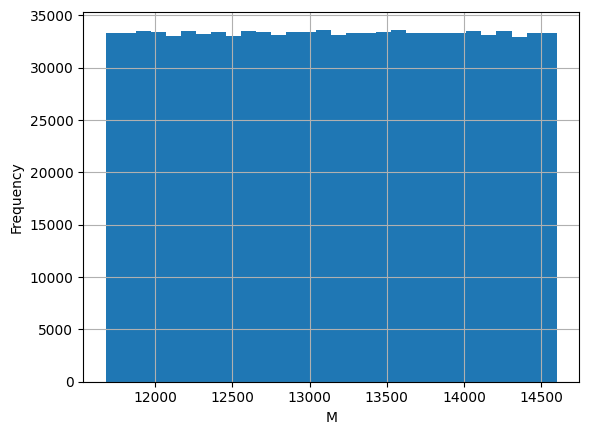


Input Variable S:
count    1000000.00
mean         320.41
std          400.05
min        -1727.95
25%           50.72
50%          321.06
75%          590.20
max         2160.77
Name: S, dtype: float64

Histogram:


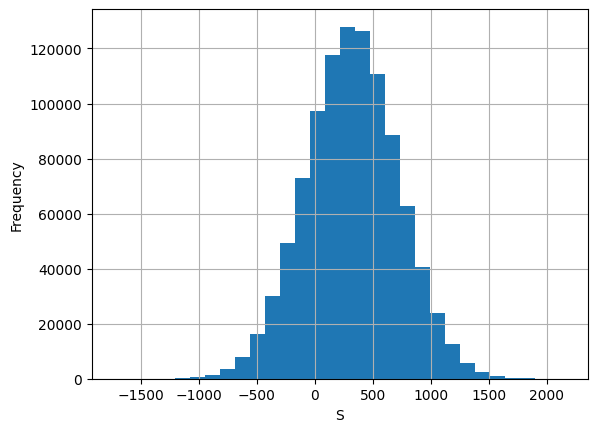


Input Variable MV:
count    1000000.00
mean       74997.62
std         5002.11
min        52077.47
25%        71622.10
50%        75003.42
75%        78372.53
max        99126.43
Name: MV, dtype: float64

Histogram:


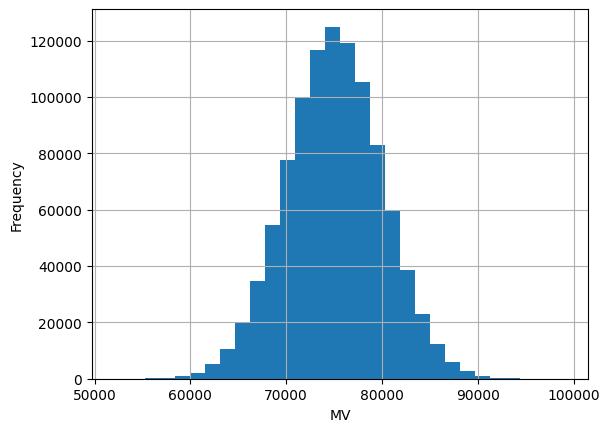

In [12]:
status3 = sim_model3.run(num_trials=1000000) 
print(status3)
sim_model3.show_inputs_values()


Output Variable PW of Alt 3:
count    1000000.00
mean     -854891.27
std       208593.05
min     -1499508.48
25%     -1002217.93
50%      -820139.79
75%      -680861.69
max      -466096.29
Name: PW of Alt 3, dtype: float64

Histogram:


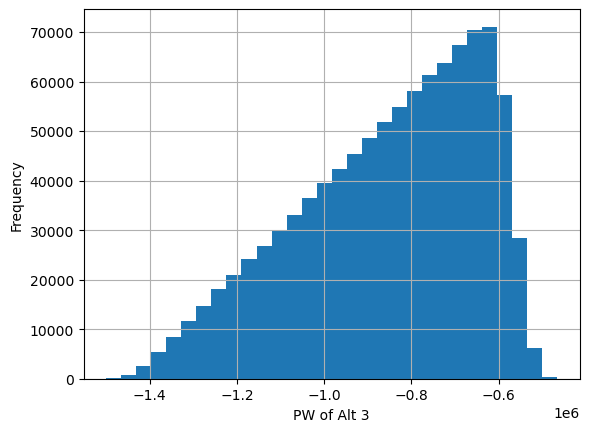

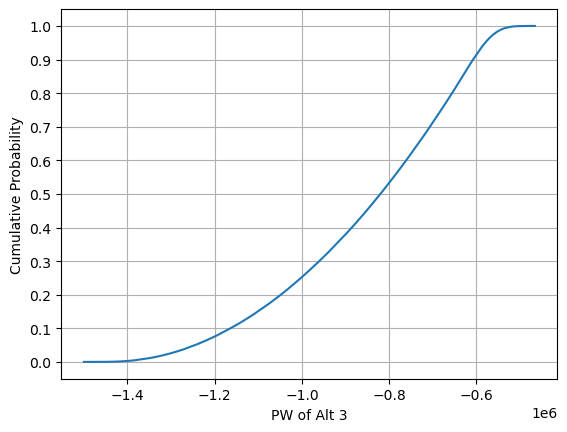

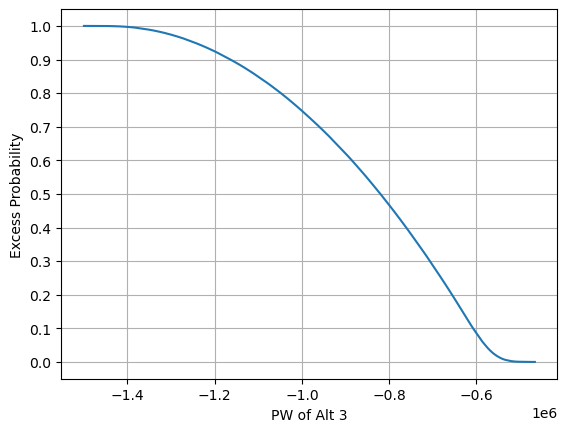


Output Variable IRR of Alt 3:
count    992477.00
mean         -1.68
std           0.20
min          -2.60
25%          -1.77
50%          -1.63
75%          -1.54
max          -1.39
Name: IRR of Alt 3, dtype: float64

Histogram:


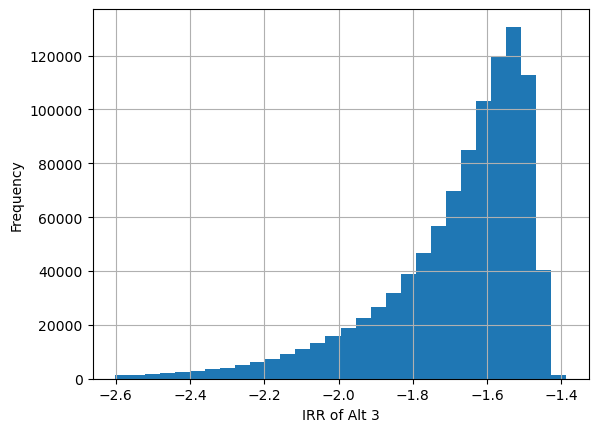

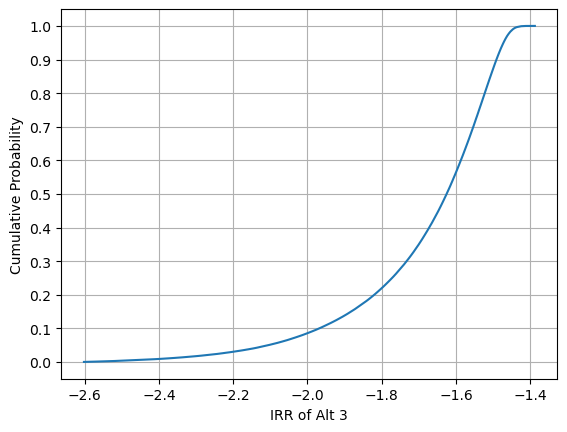

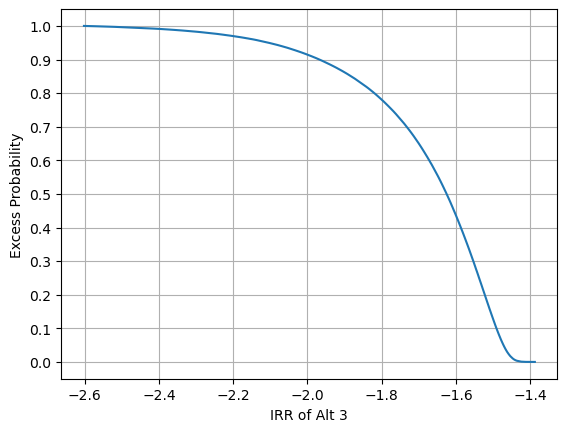

In [273]:
sim_model3.show_outputs_values()

In [279]:
sim_model3.Prob_Analysis_DCF('PW of Alt 3', 
                             downsides=[-800000,-700000,-600000, -500000], 
                             upsides=[100000])


Probabilistic Analysis on PW of Alt 3
  EV = -854,891.27
  SD = 208,592.94
Downside Risks:
  Pr(PW of Alt 3 <= -800,000) = 53.31%
  Pr(PW of Alt 3 <= -700,000) = 71.25%
  Pr(PW of Alt 3 <= -600,000) = 91.49%
  Pr(PW of Alt 3 <= -500,000) = 99.96%
Upside Potentials:
  Pr(PW of Alt 3 >= 100,000) = 0.00%
Value-at-Risk:
  VaR(99%) = 1,355,783.61
  VaR(95%) = 1,245,039.66
  VaR(90%) = 1,163,984.79


In [31]:
marr = fixed_vars['marr'] 
sim_model3.Prob_Analysis_rate('IRR of Alt 3', marr, 
                              downsides =[marr-0.05, marr-0.1, marr-0.5], 
                              upsides=[0.01, 0.15, 0.2, 0.25])


Probabilistic Analysis on IRR of Alt 3:
  EV = -168.06%
  SD = 19.53%
Downside Risks:
  Pr(IRR of Alt 3 <= 10.0%) = 100.00%
  Pr(IRR of Alt 3 <=  5.0%) = 100.00%
  Pr(IRR of Alt 3 <=  0.0%) = 100.00%
  Pr(IRR of Alt 3 <= -40.0%) = 100.00%
Upside Potentials:
  Pr(IRR of Alt 3 >=  0.0%) = 0.00%
  Pr(IRR of Alt 3 >= 15.0%) = 0.00%
  Pr(IRR of Alt 3 >= 20.0%) = 0.00%
  Pr(IRR of Alt 3 >= 25.0%) = 0.00%
